Problem Statement

Using passenger data from the Titanic disaster, build a machine learning model that predicts whether a passenger survived or not.

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix, classification_report


In [208]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
#df = pd.read_csv(data)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [209]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


EDA 
1) Understanding the data

In [210]:
df.shape

(891, 12)

In [211]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [212]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [213]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


2) Missing values


In [214]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [215]:
df.drop(columns= 'Cabin', inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [216]:
# df['Age'].fillna(df['Age'].median(), inplace=True)

df['Age']= df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [217]:
#df['Fare'].fillna(df['Fare'].median(), inplace=True)

df['Fare']= df.groupby(['Pclass','Embarked'])["Fare"].transform(
    lambda x: x.fillna(x.median())
)
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           2
Embarked       2
dtype: int64

3) Univariate Analysis (one variable at a time)

The ship was predominantly boarded by young individuals,
 with most passengers falling within the 20 to 30 age range.


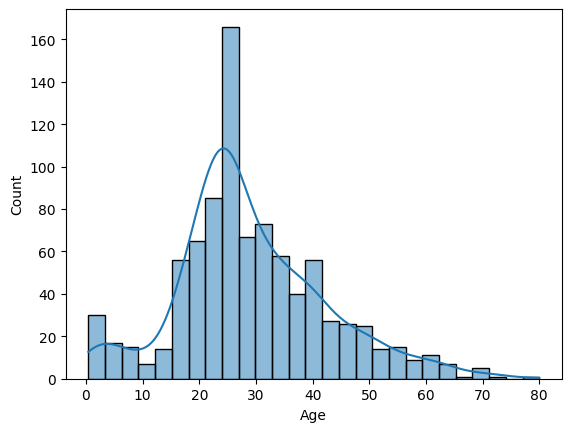

In [218]:
#Where is the peak? (young / middle age / old)
sns.histplot(df['Age'], kde=True)  
print("The ship was predominantly boarded by young individuals,\n with most passengers falling within the 20 to 30 age range.")

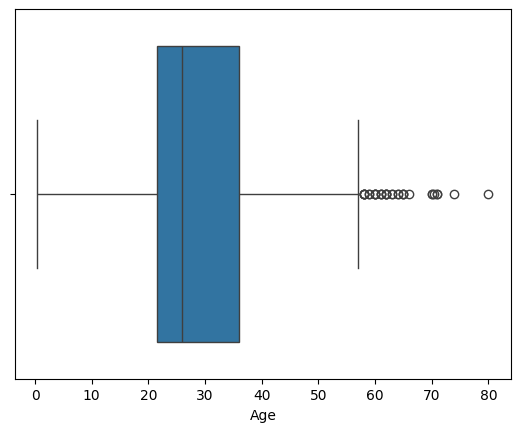

The distribution is right-skewed (positively skewed) 
The right whisker is longer and there are several points extending toward higher ages
Yes, there are outliers on the higher end: Around 60–75 years
Most passengers are concentrated roughly between 20 and 40 years
A few older individuals pull the distribution to the right


In [219]:
#Is it skewed?
#Any extreme values?

sns.boxplot(x=df["Age"])
plt.show()
print("The distribution is right-skewed (positively skewed) \nThe right whisker is longer and there are several points extending toward higher ages")
print("Yes, there are outliers on the higher end: Around 60–75 years")
print("Most passengers are concentrated roughly between 20 and 40 years")
print("A few older individuals pull the distribution to the right")

In [220]:

#more MEN or Women
print(df["Sex"].unique())
print(df["Sex"].value_counts(dropna=False))

<StringArray>
['male', 'female']
Length: 2, dtype: str
Sex
male      577
female    314
Name: count, dtype: int64


In [221]:
print(df["Survived"].unique())
print(df["Survived"].value_counts())

[0 1]
Survived
0    549
1    342
Name: count, dtype: int64


In [222]:
print(df.groupby("Sex")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


4) Bivariate Analysis w Survival


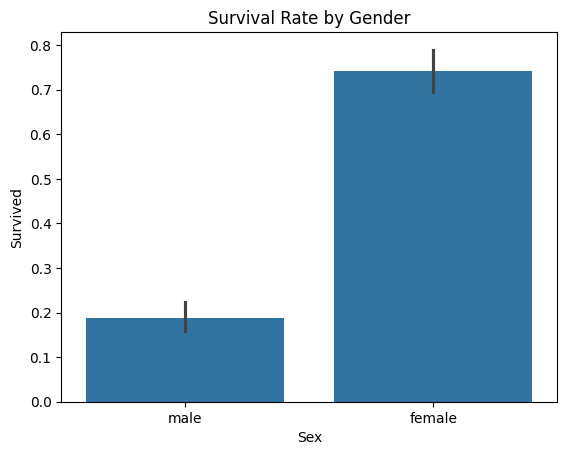

In [223]:
#It plots average survival rate (0 = died, 1 = survived)

sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

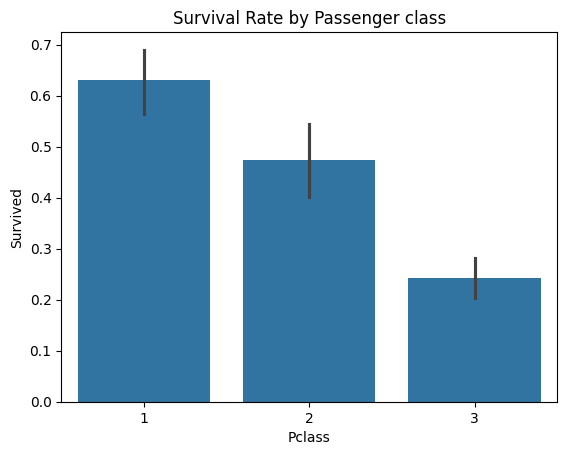

In [224]:
#Compare survival across classes

sns.barplot(x='Pclass',y='Survived', data=df)
plt.title("Survival Rate by Passenger class")
plt.show()

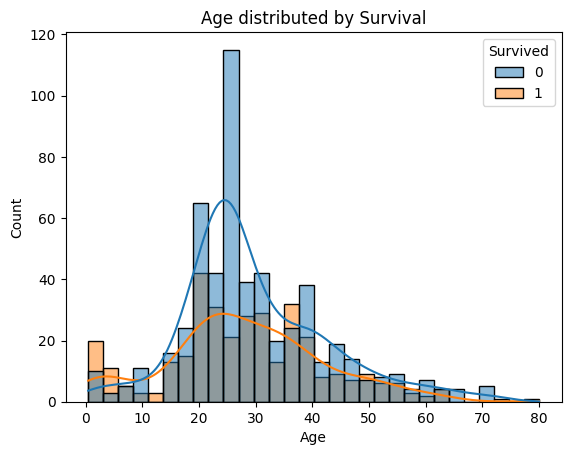

Children: Higher survival rate 
Adults: Mixed survival 
Older passengers: Lower survival probability


In [225]:
#Survival of age groups
sns.histplot(x="Age",hue="Survived",bins=30, kde=True, data=df)
plt.title('Age distributed by Survival')
plt.show()
print("Children: Higher survival rate \nAdults: Mixed survival \nOlder passengers: Lower survival probability")

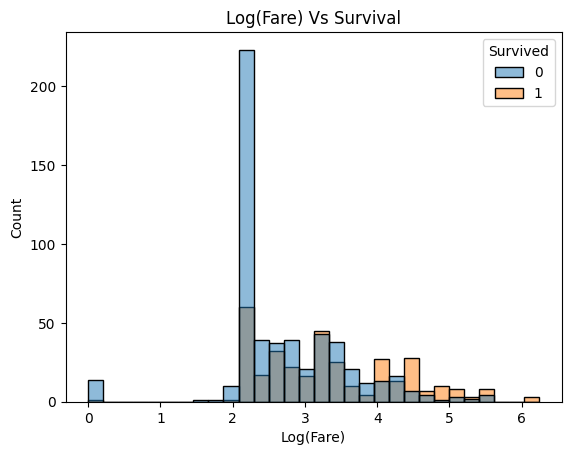

Survivors → higher median fare
Non-survivors → lower fare


In [226]:
#Do survivours pay high?
sns.histplot(x=np.log1p(df["Fare"]),hue="Survived",bins=30 ,data=df)
plt.title("Log(Fare) Vs Survival")
plt.xlabel('Log(Fare)')
plt.show()
print("Survivors → higher median fare\nNon-survivors → lower fare")

In [227]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')


In [228]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Text(0.5, 1.0, 'Survival by Passenger class')

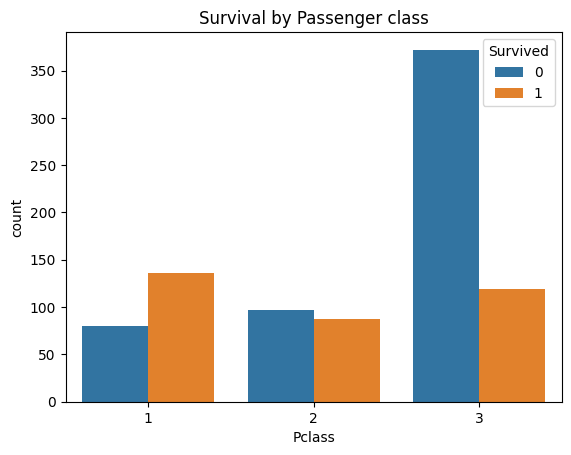

In [229]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger class')

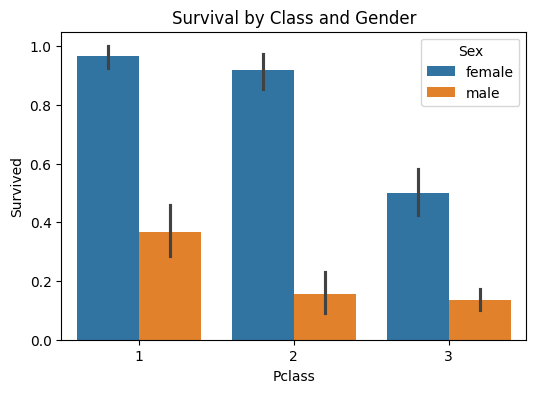

In [230]:
#Survival by class and gender
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=df, estimator='mean')
plt.title("Survival by Class and Gender")
plt.show()

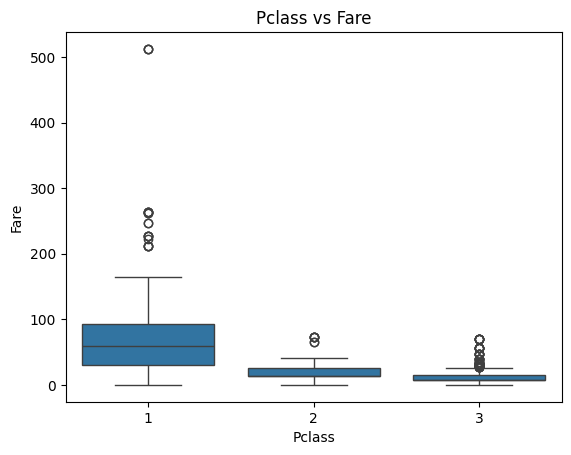

1st class → very high fares 
2nd class → medium 
3rd class → low


In [231]:
#Pclass vs Fare

sns.boxplot(x='Pclass',y='Fare',data=df)
plt.title("Pclass vs Fare")
plt.show()
print(f'1st class → very high fares \n2nd class → medium \n3rd class → low')

5) Feature relationships


In [232]:
#FAMILY SIZE
df["Familysize"] = df["SibSp"]+df["Parch"]+1
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Familysize'],
      dtype='str')

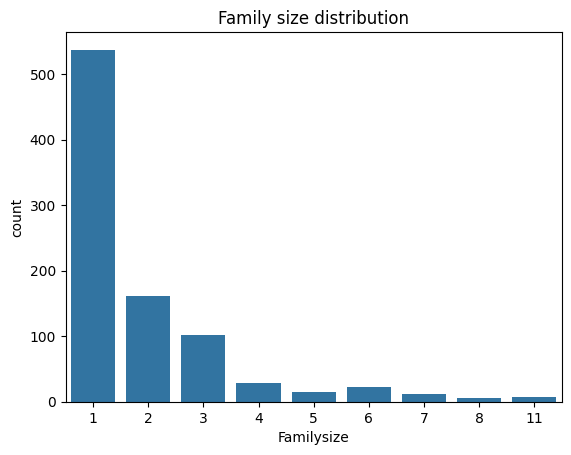

In [233]:
sns.countplot(x="Familysize",data=df)
plt.title("Family size distribution")
plt.show()

In [234]:
#Alone
df["IsAlone"]= (df['Familysize']==1).astype(int)
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Familysize', 'IsAlone'],
      dtype='str')

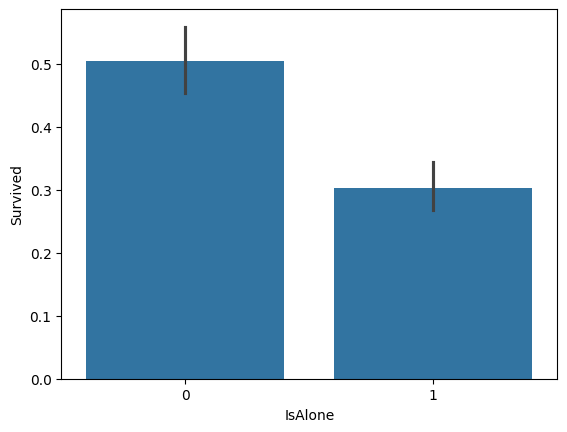

In [235]:
sns.barplot(x="IsAlone", y='Survived', data=df)
plt.show()

In [236]:
#FARE for the Trip
df["FarePerPerson"]= df["Fare"]/df['Familysize']
print(df["FarePerPerson"])
print(f"Fare is strongly correlated with passenger class \nPassengers in higher classes paid significantly more \nFamily size impacts survival probability \nSmall families had better survival rates \nSolo passengers had lower survival chances \nLarge families also faced lower survival")


0       3.62500
1      35.64165
2       7.92500
3      26.55000
4       8.05000
         ...   
886    13.00000
887    30.00000
888     5.86250
889    30.00000
890     7.75000
Name: FarePerPerson, Length: 891, dtype: float64
Fare is strongly correlated with passenger class 
Passengers in higher classes paid significantly more 
Family size impacts survival probability 
Small families had better survival rates 
Solo passengers had lower survival chances 
Large families also faced lower survival


6. Correlation Analysis

In [237]:
df.dtypes

PassengerId        int64
Survived           int64
Pclass             int64
Name                 str
Sex                  str
Age              float64
SibSp              int64
Parch              int64
Ticket               str
Fare             float64
Embarked             str
Familysize         int64
IsAlone            int64
FarePerPerson    float64
dtype: object

In [238]:
#correlation matrix
num_cols =["Survived", "Pclass","Age","Fare","SibSp","Parch","Familysize","IsAlone"]
corr = df[num_cols].corr()
print(corr)

            Survived    Pclass       Age      Fare     SibSp     Parch  \
Survived    1.000000 -0.338481 -0.059579  0.255290 -0.035322  0.081629   
Pclass     -0.338481  1.000000 -0.413583 -0.548193  0.083081  0.018443   
Age        -0.059579 -0.413583  1.000000  0.119859 -0.249854 -0.175526   
Fare        0.255290 -0.548193  0.119859  1.000000  0.160887  0.217532   
SibSp      -0.035322  0.083081 -0.249854  0.160887  1.000000  0.414838   
Parch       0.081629  0.018443 -0.175526  0.217532  0.414838  1.000000   
Familysize  0.016639  0.065997 -0.258456  0.218658  0.890712  0.783111   
IsAlone    -0.203367  0.135207  0.175529 -0.274079 -0.584471 -0.583398   

            Familysize   IsAlone  
Survived      0.016639 -0.203367  
Pclass        0.065997  0.135207  
Age          -0.258456  0.175529  
Fare          0.218658 -0.274079  
SibSp         0.890712 -0.584471  
Parch         0.783111 -0.583398  
Familysize    1.000000 -0.690922  
IsAlone      -0.690922  1.000000  


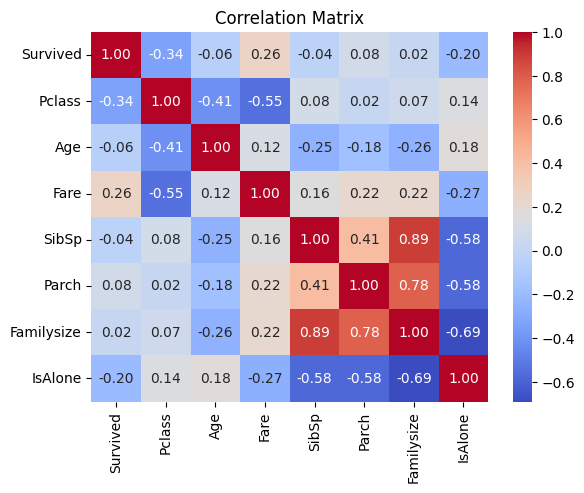

In [239]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

7. Feature Engineering (High Impact)

In [240]:
df["Title"]= df["Name"].str.extract(r'([A-Za-z]+)\.', expand=False)
df["Title"].value_counts()

df["Title"]= df["Title"].replace(
    ['Col',"Dona","Dr","Ms","Rev",],
    "Rare"
)
print(df["Title"])


0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886    Rare
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: str


In [241]:
common_titles = ['Mr','Mrs','Miss','Master']
df["Title"] = df["Title"].apply(
    lambda x: x if x in common_titles else "Rare"
)
df["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886    Rare
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: str

In [242]:
print(df['Sex'].dtype)
print(df["Sex"].head(15))


str
0       male
1     female
2     female
3     female
4       male
5       male
6       male
7       male
8     female
9     female
10    female
11    female
12      male
13      male
14    female
Name: Sex, dtype: str


In [243]:
df["Sex"]= df["Sex"].map({'male':0, 'female':1})
print(df["Sex"])

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64


In [244]:
#"C" = Cherbourg, "Q" = Queenstown, "S" = Southampton
df["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [245]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
#df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


In [246]:
#drop unnecessary
df.drop(columns=['Name',"Ticket",'PassengerId'], inplace=True)
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Familysize,IsAlone,FarePerPerson,Title,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,Mr,False,True
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,Mrs,False,False
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,Miss,False,True
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,Mrs,False,True
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,Mr,False,True
5,0,3,0,25.0,0,0,8.4583,1,1,8.45830,Mr,True,False
6,0,1,0,54.0,0,0,51.8625,1,1,51.86250,Mr,False,True
7,0,3,0,2.0,3,1,21.0750,5,0,4.21500,Master,False,True
8,1,3,1,27.0,0,2,11.1333,3,0,3.71110,Mrs,False,True
9,1,2,1,14.0,1,0,30.0708,2,0,15.03540,Mrs,False,False
